# Car Price Prediction(Toyota Corolla)
* Dataset Overview
    * Source: Kaggle/GitHub
    * Size: 1,436 entries
    * Attributes (37 total):
    * Price (in Euros)
    * Age (in months)
    * Manufacturing year & month
    * KM (mileage) → accumulated kilometers
    * Fuel_Type (Petrol, Diesel, CNG)
    * HP (horsepower)
    * cc (engine size in cubic centimeters)
    * Doors, Cylinders, Gears
    * Quarterly_Tax (road tax in Euros)
    * Weight (kg)
    * Guarantee info (manufacturer, dealer)
    * Features: ABS, airbags, air conditioning, board computer, CD player, central lock, powered windows, power steering, radio, sport model, tow bar, etc.
     

In [5]:
import numpy as np 
data=np.genfromtxt("dataFile/sales.csv",delimiter=",",skip_header=1)
print("Data Shape: ",data.shape)

Data Shape:  (1436, 37)


In [ ]:
# Features extraction
price=data[:,2]
age=data[:,3]
km=data[:,6]
cc=data[:,11]

[23. 23. 24. ... 71. 70. 76.]


In [10]:
# Design Matrix
ones=np.ones((len(price),1))
X=np.column_stack([ones,age,km,cc])

In [11]:
# Regression
Xt=np.transpose(X)
XtX=Xt @ X
w=np.linalg.inv(XtX) @ Xt @ price
np.set_printoptions(suppress=True,precision=4)
print("Weights: ",np.round(w,2))


Weights:  [19492.93  -151.43    -0.02     0.59]


* Intercept (bias term) = 19,492.93  
→ This is the baseline price (in Euros) when age, mileage, and engine size are set to zero. Of course, no car has zero age or mileage, but mathematically it anchors the regression line.

* Coefficient for Age = -151.43  
→ For each additional month of age, the car’s price decreases by about €151. This captures depreciation over time.

* Coefficient for Mileage (KM) = -0.02  
→ For each extra kilometer driven, the price decreases by about €0.02. In other words, 10,000 km reduces the price by roughly €200.

* Coefficient for Engine Size (cc) = 0.59  
→ For each additional cubic centimeter of engine size, the price increases by about €0.59. So a 200cc larger engine adds about €118 to the price.

In [12]:
# Fit & Error
y_pred=X @ w
mse = np.mean((price-y_pred)**2)
rmse=np.sqrt(mse)
print("Mean Square Error: ",mse)
print("Root Mean Square Error: ",rmse)

Mean Square Error:  2700613.4845706066
Root Mean Square Error:  1643.354339322657


* Mean Square Error (MSE) = 2,700,613.48  
→ This is the average of the squared differences between actual and predicted car prices. It shows how far off the model is overall, with large errors penalized more heavily.

* Root Mean Square Error (RMSE) = 1,643.35  
→ This is the square root of MSE, expressed in Euros. It represents the typical prediction error size. In this case, the model’s average miss is about €1,643 per car listing.

In [20]:
# Prediction dummy car price:
features=np.array([1,data[50,3],data[50,6],data[50,11]]) # bias,age,km,cc
dummy_pred=features @ w
print("Predicted price: €",np.round(dummy_pred,2))
print("Actual price: €",data[50,2])

Predicted price: € 16226.69
Actual price: € 17950.0


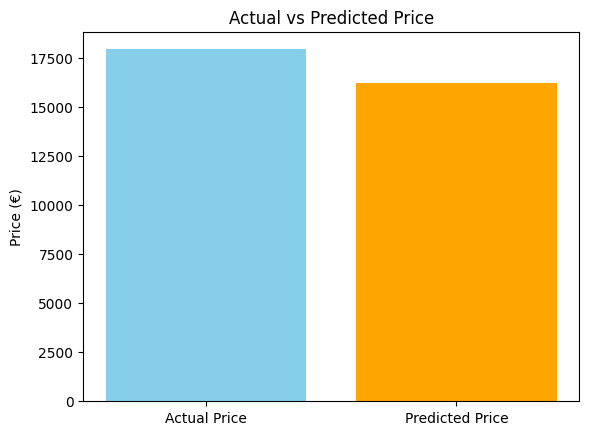

In [26]:
import matplotlib.pyplot as plt

# Example values
actual_price = data[50,2]
predicted_price = dummy_pred 

# Labels and values
labels = ["Actual Price", "Predicted Price"]
values = [actual_price, predicted_price]

# Create bar chart
plt.bar(labels, values, color=["skyblue", "orange"])
plt.ylabel("Price (€)")
plt.title("Actual vs Predicted Price")

# Show the chart
plt.show()


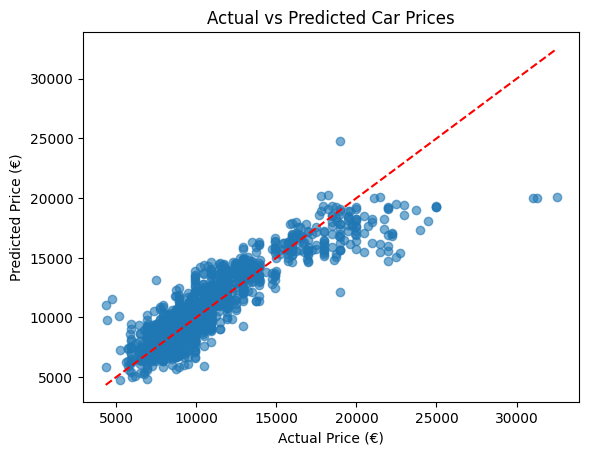

In [21]:
# Actual vs Predicted price
import matplotlib.pyplot as plt

plt.scatter(price, y_pred, alpha=0.6)
plt.xlabel("Actual Price (€)")
plt.ylabel("Predicted Price (€)")
plt.title("Actual vs Predicted Car Prices")
plt.plot([price.min(), price.max()], [price.min(), price.max()], 'r--')  # perfect fit line
plt.show()


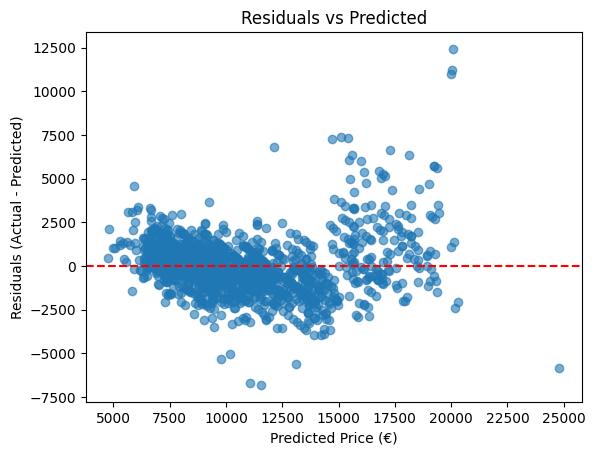

In [22]:
residuals = price - y_pred

plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price (€)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted")
plt.show()


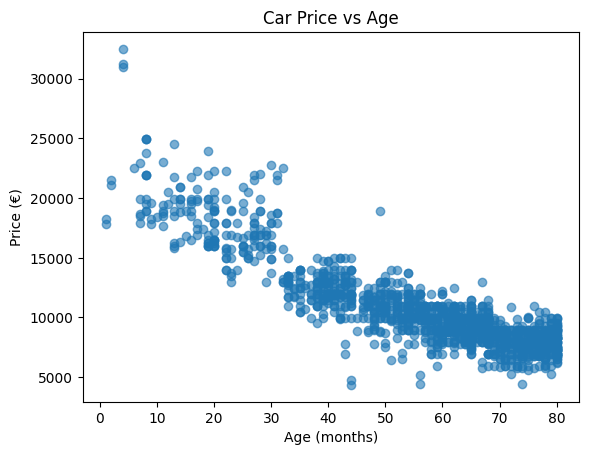

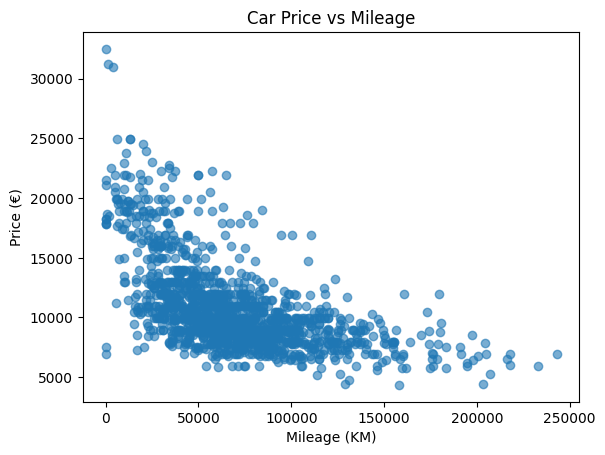

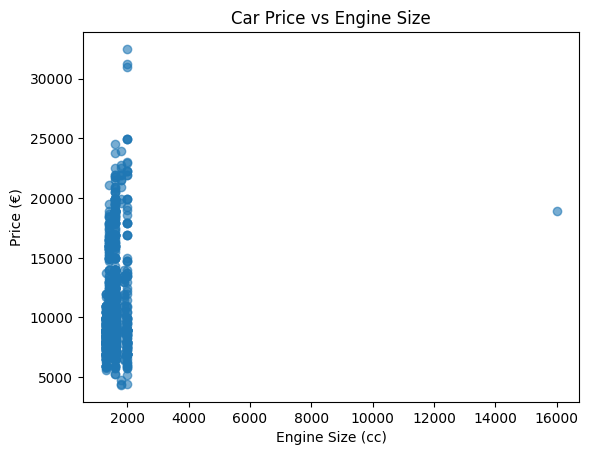

In [23]:
plt.scatter(age, price, alpha=0.6)
plt.xlabel("Age (months)")
plt.ylabel("Price (€)")
plt.title("Car Price vs Age")
plt.show()

plt.scatter(km, price, alpha=0.6)
plt.xlabel("Mileage (KM)")
plt.ylabel("Price (€)")
plt.title("Car Price vs Mileage")
plt.show()

plt.scatter(cc, price, alpha=0.6)
plt.xlabel("Engine Size (cc)")
plt.ylabel("Price (€)")
plt.title("Car Price vs Engine Size")
plt.show()
